# Dual FEG

We consider a monotone and $L$-Lipschitz continuous operator $A$ with a zero $x_\star$, so $A(x_\star)=0$, and an initial point satisfying $\|x_0-x_\star\|^2 \le R^2$. We use stepsize $\alpha = 1/L$ and initialize $z_0=0$. The performance metric for this Block 1 reproduction is the squared residual $\|A(x_N)\|^2$.

For $k=0,\ldots,N-1$, Dual FEG is

$$
x_{k+1/2} = x_k - \alpha z_k - \alpha A(x_k),
$$

$$
x_{k+1} = x_{k+1/2} - \frac{N-k-1}{N-k}\alpha\left(A(x_{k+1/2}) - A(x_k)\right),
$$

$$
z_{k+1} = \frac{N-k-1}{N-k} z_k - \frac{1}{N-k} A(x_{k+1/2}).
$$

## Proof Statement

### Theorem
Assume $A$ is monotone and $L$-Lipschitz continuous, $A(x_{\star})=0$, and $\|x_{0}-x_{\star}\|^{2}\le R^{2}$. Let Dual FEG use $\alpha=1/L$ and $z_{0}=0$:

$$
x_{k+1/2}=x_{k}-\alpha z_{k}-\alpha A(x_{k}),
$$

$$
x_{k+1}=x_{k+1/2}-\frac{N-k-1}{N-k}\alpha\left(A(x_{k+1/2})-A(x_{k})\right),
$$

$$
z_{k+1}=\frac{N-k-1}{N-k}z_{k}-\frac{1}{N-k}A(x_{k+1/2}).
$$

For $N\ge 2$, define $V_{0}=0$. For $1\le k\le N-1$,

$$
V_{k}=2\|A(x_{N})\|^{2}-2\|z_{k}+A(x_{N})\|^{2}
-\frac{4L}{N}\langle A(x_{N}),x_{0}-x_{N}\rangle
+\frac{4L}{N-k}\langle z_{k}+A(x_{N}),x_{k}-x_{N}\rangle.
$$

The terminal term is

$$
V_{N}=V_{N-1}+2I^{\rm lip}(x_{N-1},x_{N}).
$$

Then

$$
\|A(x_{N})\|^{2}\le \frac{4L^{2}}{N^{2}}\|x_{0}-x_{\star}\|^{2}\le \frac{4L^{2}R^{2}}{N^{2}}.
$$

### Proof outline
Use the nonpositive residuals

$$
I^{\rm lip}(u,v)=\|A(u)-A(v)\|^{2}-L^{2}\|u-v\|^{2}\le 0,
\qquad
I^{\rm mon}(u,v)=-\langle A(u)-A(v),u-v\rangle\le 0.
$$

The Lyapunov function is the closed-form $V_{k}$ stated above. Its increments satisfy the exact identities

$$
V_{1}-V_{0}=\frac{2}{N^{2}}I^{\rm lip}(x_{0},x_{1/2})
+\frac{4L}{(N-1)N}I^{\rm mon}(x_{1/2},x_{N}),
$$

and, for $1\le k\le N-2$,

$$
V_{k+1}-V_{k}=\frac{2}{(N-k)^{2}}I^{\rm lip}(x_{k},x_{k+1/2})
+\frac{4L}{(N-k-1)(N-k)}I^{\rm mon}(x_{k+1/2},x_{N}).
$$

The final increment is

$$
V_{N}-V_{N-1}=2I^{\rm lip}(x_{N-1},x_{N}).
$$

All coefficients are nonnegative and all residuals are nonpositive, so $V_{N}\le V_{0}=0$. The boundary identity is

$$
\|A(x_{N})\|^{2}-\frac{4L^{2}}{N^{2}}\|x_{0}-x_{\star}\|^{2}
-V_{N}-\frac{4L}{N}I^{\rm mon}(x_{N},x_{\star})
+\left\|A(x_{N})-\frac{2L}{N}(x_{0}-x_{\star})\right\|^{2}=0.
$$

Since $-V_{N}\ge 0$, $-I^{\rm mon}(x_{N},x_{\star})\ge 0$, and the square is nonnegative, the claimed residual bound follows.

In [1]:
from pathlib import Path
import itertools
import json
from fractions import Fraction
import importlib.util
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import sympy as sp  # noqa: E402

import pepflow as pf  # noqa: E402
from pepflow.lyapunov_utils import (  # noqa: E402
    find_symmetric_coefficient_matrix,
    vectors_in_column_space,
)

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
A = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A"], L=L)

In [3]:
def make_ctx_dual_feg(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    """Build the PEPContext encoding N steps of Dual FEG."""
    N_int = int(N)
    ctx = pf.PEPContext(ctx_name).set_as_current()

    x = pf.Vector(is_basis=True, tags=["x_0"])
    z = pf.Vector.zero().add_tag("z_0")
    A.set_zero_point("x_star")

    alpha = sp.S(1) / L
    for k in range(N_int):
        weight = sp.Rational(N_int - k - 1, N_int - k)
        inv_remaining = sp.Rational(1, N_int - k)

        Ax = A(x)
        x_half = x - alpha * z - alpha * Ax
        x_half.add_tag(f"x_{k + 0.5}")
        Ax_half = A(x_half)

        x = x_half - weight * alpha * (Ax_half - Ax)
        x.add_tag(f"x_{k + 1}")

        z = weight * z - inv_remaining * Ax_half
        z.add_tag(f"z_{k + 1}")

    return ctx


def get_pep_setup(N, params):
    """Standard interface for pep_runner.py."""
    ctx = make_ctx_dual_feg(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(A(ctx[f"x_{N}"]) ** 2)
    return ctx, pb, A

N    PEP value      rate guess      fraction
1    1.99999864     2.00000000     2
2    1.00005152     1.00000000     1
3    0.44447345     0.44444444     4/9
4    0.25000040     0.25000000     1/4
5    0.16000072     0.16000000     4/25
6    0.11111809     0.11111111     1/9
7    0.08163549     0.08163265     4/49


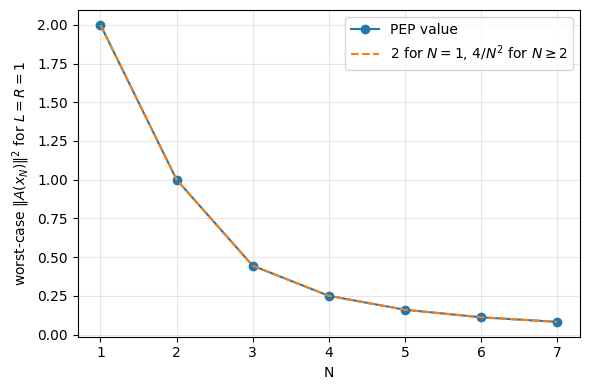

In [4]:
state_path = ROOT / "examples_peppy" / "dual-feg" / "state" / "dual_feg_b1.json"
state = json.loads(state_path.read_text())
results = state["sweep_results"]
Ns = [row["N"] for row in results]
values = [float(row["opt_value"]) for row in results]
rate_guess = [2.0 if N == 1 else 4.0 / (N * N) for N in Ns]

print("N    PEP value      rate guess      fraction")
for N, value, guess in zip(Ns, values, rate_guess):
    print(
        f"{N:<4} {value:<14.8f} {guess:<14.8f} {Fraction(value).limit_denominator(1000)}"
    )

plt.figure(figsize=(6, 4))
plt.plot(Ns, values, "o-", label="PEP value")
plt.plot(Ns, rate_guess, "--", label=r"$2$ for $N=1$, $4/N^2$ for $N\geq 2$")
plt.xlabel("N")
plt.ylabel(r"worst-case $\|A(x_N)\|^2$ for $L=R=1$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Block 1 Conjecture

The numerical sweep supports

$$
\|A(x_N)\|^2 \le
\begin{cases}
2L^2R^2, & N=1,\
\dfrac{4L^2R^2}{N^2}, & N\ge 2.
\end{cases}
$$

The remaining sections are placeholders for later proof blocks.

## Dense and Relaxed Proof Solves

For Block 2 we solve the dense PEP at `N_verify = 4`, then impose the sparse support suggested by the dense dual certificate. The retained interpolation inequalities are

$$
I^{\rm mon}(x_{h+1/2}, x_N),\quad h=0,\ldots,N-2,
\qquad I^{\rm mon}(x_N,x_\star),
$$

and

$$
I^{\rm lip}(x_i,x_{i+1/2}),\quad i=0,\ldots,N-2,
\qquad I^{\rm lip}(x_{N-1},x_N).
$$

Both residual conventions are nonpositive, so nonnegative multipliers can be accumulated directly in the proof identity.

In [5]:
state_dir = ROOT / "examples_peppy" / "dual-feg" / "state"
dense = json.loads((state_dir / "dual_feg_dense.json").read_text())
b2 = json.loads((state_dir / "dual_feg_b2.json").read_text())
b5 = json.loads((state_dir / "dual_feg_b5.json").read_text())

print(f"Dense opt value:   {float(dense['opt_value']):.9f}")
print(f"Relaxed opt value: {float(b2['opt_value']):.9f}")
print(f"Rate at N=4:       {4 / b2['N_verify'] ** 2:.9f}")
print(
    f"Relaxation preserved optimum: {abs(float(dense['opt_value']) - float(b2['opt_value'])) < 1e-5}"
)
print("Basis vectors:", b2["basis_vectors"])

for name, cert in [("Dense", dense), ("Relaxed", b2)]:
    print()
    print(f"{name} lambda matrices:")
    for group, payload in cert["lambda_groups"].items():
        print(group)
        matrix = np.array(payload["matrix"], dtype=float)
        pf.pprint_labeled_matrix(
            matrix, payload["row_names"], payload["col_names"], precision=3
        )

Dense opt value:   0.250000404
Relaxed opt value: 0.250001200
Rate at N=4:       0.250000000
Relaxation preserved optimum: True
Basis vectors: ['x_0', 'x_star', 'A(x_0)', 'A(x_0.5)', 'A(x_1)', 'A(x_1.5)', 'A(x_2)', 'A(x_2.5)', 'A(x_3)', 'A(x_3.5)', 'A(x_4)']

Dense lambda matrices:
Monotone Operator Inequality


<IPython.core.display.Math object>

Lipschitz Continuous Inequality


<IPython.core.display.Math object>


Relaxed lambda matrices:
Monotone Operator Inequality


<IPython.core.display.Math object>

Lipschitz Continuous Inequality


<IPython.core.display.Math object>

## Closed-Form Lambda and S Verification

The relaxed certificate is captured by the following closed-form multipliers:

$$
\lambda^{\rm mon}_{h+1/2,N}=\frac{4}{(N-h-1)(N-h)},\quad h=0,\ldots,N-2,
\qquad
\lambda^{\rm mon}_{N,\star}=\frac{4}{N},
$$

$$
\lambda^{\rm lip}_{i,i+1/2}=\frac{2}{(N-i)^2},\quad i=0,\ldots,N-2,
\qquad
\lambda^{\rm lip}_{N-1,N}=2.
$$

The Gram certificate is the rank-one square

$$
S = \left\|A(x_N)-\frac{2L}{N}(x_0-x_\star)\right\|^2.
$$

In [6]:
N_int = b2["N_verify"]


def lamb_mono(ri, ci, N=N_int):
    for h in range(N - 1):
        if ri == f"x_{h}.5" and ci == f"x_{N}":
            return sp.Rational(4, (N - h - 1) * (N - h))
    if ri == f"x_{N}" and ci == "x_star":
        return sp.Rational(4, N)
    return sp.S(0)


def lamb_lip(ri, ci, N=N_int):
    for i in range(N - 1):
        if ri == f"x_{i}" and ci == f"x_{i}.5":
            return sp.Rational(2, (N - i) ** 2)
    if ri == f"x_{N - 1}" and ci == f"x_{N}":
        return sp.S(2)
    return sp.S(0)


def lamb(group, ri, ci, N=N_int):
    if group == "Monotone Operator Inequality":
        return lamb_mono(ri, ci, N)
    if group == "Lipschitz Continuous Inequality":
        return lamb_lip(ri, ci, N)
    return sp.S(0)


for group, payload in b2["lambda_groups"].items():
    rows = payload["row_names"]
    cols = payload["col_names"]
    candidate = np.array(
        [[lamb(group, ri, ci, N_int) for ci in cols] for ri in rows], dtype=object
    )
    numeric = payload["matrix"]
    max_resid = max(
        abs(float(candidate[i][j]) - float(numeric[i][j]))
        for i in range(len(rows))
        for j in range(len(cols))
    )
    print(f"{group} closed-form max residual: {max_resid:.3e}")
    pf.pprint_labeled_matrix(candidate, rows, cols, precision=0)

Monotone Operator Inequality closed-form max residual: 3.964e-06


<IPython.core.display.Math object>

Lipschitz Continuous Inequality closed-form max residual: 3.920e-06


<IPython.core.display.Math object>

In [7]:
spec = importlib.util.spec_from_file_location("dual_feg_setup", ROOT / b2["setup_file"])
if spec is None or spec.loader is None:
    raise ImportError("Could not load Dual FEG setup module")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

ctx, pb, obj = setup.get_pep_setup(sp.S(N_int), {"L": sp.S(1), "R": sp.S(1)})
pm = pf.ExpressionManager(ctx, resolve_parameters={"L": sp.S(1), "R": sp.S(1)})
L = setup.L
S_guess = (obj(ctx[f"x_{N_int}"]) - (2 * L / N_int) * (ctx["x_0"] - ctx["x_star"])) ** 2
S_guess_matrix = pm.eval_scalar(S_guess).inner_prod_coords.astype(float)
S_numeric = np.array(b2["S_matrix"], dtype=float)
print("Stored S certificate matrix:")
pf.pprint_labeled_matrix(S_numeric, b2["S_row_names"], b2["S_col_names"], precision=3)
print("Stored guessed S formula:")
pf.pprint_str(b5["S_formula"])
print("S matches relaxed matrix:", np.allclose(S_guess_matrix, S_numeric, atol=5e-5))
print("S candidate rank:", np.linalg.matrix_rank(S_guess_matrix, tol=1e-8))

Stored S certificate matrix:


<IPython.core.display.Math object>

Stored guessed S formula:


<IPython.core.display.Math object>

S matches relaxed matrix: True
S candidate rank: 1


## Full Proof Identity

For each checked $N$, the verified identity is

$$
\|A(x_N)\|^2 - \frac{4L^2}{N^2}\|x_0-x_\star\|^2
- \sum \lambda I + S = 0,
$$

where every retained interpolation residual $I$ is nonpositive and $S\succeq 0$. Therefore

$$
\|A(x_N)\|^2 \le \frac{4L^2}{N^2}\|x_0-x_\star\|^2,\qquad N\ge 2.
$$

In [8]:
def proof_residual_for_N(N_int):
    ctx, pb, obj = setup.get_pep_setup(sp.S(N_int), {"L": sp.S(1), "R": sp.S(1)})
    pm = pf.ExpressionManager(ctx, resolve_parameters={"L": sp.S(1), "R": sp.S(1)})
    rows = ["x_0"]
    for i in range(N_int):
        rows.append(f"x_{i}.5")
        rows.append(f"x_{i + 1}")
    cols = rows[1:] + ["x_star"]

    interp_sum = pf.Scalar.zero()
    for ri, ci in itertools.product(rows, cols):
        cm = lamb_mono(ri, ci, N_int)
        if cm != 0:
            interp_sum += cm * obj.monotone_ineq(ri, ci)
        cl = lamb_lip(ri, ci, N_int)
        if cl != 0:
            interp_sum += cl * obj.lipschitz_ineq(ri, ci)

    x_N = ctx[f"x_{N_int}"]
    x_0 = ctx["x_0"]
    x_star = ctx["x_star"]
    L = setup.L
    perf = obj(x_N) ** 2
    initial = (x_0 - x_star) ** 2
    rate = sp.Rational(4, N_int**2) * L**2
    S_guess = (obj(x_N) - (sp.Rational(2, N_int) * L) * (x_0 - x_star)) ** 2
    diff = perf - rate * initial - interp_sum + S_guess
    rep = pm.eval_scalar(diff)
    return float(np.max(np.abs(rep.inner_prod_coords.astype(float))))


residuals = {N: proof_residual_for_N(N) for N in range(2, 8)}
for N, residual in residuals.items():
    print(f"N={N}: proof residual {residual:.3e}")
print("Proof valid:", max(residuals.values()) < 1e-12)

C:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\pep_context.py:172: UserWarning:

The provided name was already used. The older PEPContext will be overwritten. PEPBuilders constructed with the older PEPContext should be remade.



N=2: proof residual 0.000e+00
N=3: proof residual 1.110e-16
N=4: proof residual 6.939e-17
N=5: proof residual 1.110e-16
N=6: proof residual 8.327e-17
N=7: proof residual 1.110e-16
Proof valid: True


## Partial-Sum Lyapunov Construction and Rank Profile

Block 3 groups the closed-form Block 2 certificate into stepwise residual sums. With the residual conventions

$$
I^{\rm mon}(u,v)=-\langle A(u)-A(v),u-v\rangle\le 0,
\qquad
I^{\rm lip}(u,v)=\|A(u)-A(v)\|^2-L^2\|u-v\|^2\le 0,
$$

we use the nonincreasing convention

$$
V_{k+1}-V_k
=\frac{2}{(N-k)^2}I^{\rm lip}(x_k,x_{k+1/2})
+\frac{4}{(N-k-1)(N-k)}I^{\rm mon}(x_{k+1/2},x_N),
\quad k=0,\ldots,N-2,
$$

and the final increment

$$
V_N-V_{N-1}=2I^{\rm lip}(x_{N-1},x_N).
$$

Thus each increment is nonpositive. The rank profile identifies the fixed-dimensional subspace used by the interior Lyapunov terms; the remaining terminal rank is a boundary term handled together with the rank-one $S$ certificate from Block 2.

In [9]:
b3 = json.loads((state_dir / "dual_feg_b3.json").read_text())
print("S ingredient:", b3["S_piece_code"])
print("Monotonicity direction:", b3["monotonicity_direction"])
print("Extra duals:", b3["extra_duals"])

S ingredient: S is kept as the rank-one boundary term from Block 2; no per-step S pieces are subtracted in V_k.
Monotonicity direction: V_{k+1} - V_k is a nonnegative combination of nonpositive monotone/Lipschitz residuals, hence V_{k+1} <= V_k.
Extra duals: {}


In [10]:
# Recreate the Block 3 context and visible partial-sum construction.
N_int = b3["N_verify"]
ctx, pb, obj = setup.get_pep_setup(sp.S(N_int), {"L": sp.S(1), "R": sp.S(1)})
pm = pf.ExpressionManager(ctx, resolve_parameters={"L": sp.S(1), "R": sp.S(1)})


def mono_weight(h, N=N_int):
    return sp.Rational(4, (N - h - 1) * (N - h))


def lip_weight(i, N=N_int):
    return sp.Rational(2, (N - i) ** 2)


lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for step in range(N_int):
    if step < N_int - 1:
        partial_sum = partial_sum + lip_weight(step) * obj.lipschitz_ineq(
            f"x_{step}", f"x_{step}.5", ctx
        )
        partial_sum = partial_sum + mono_weight(step) * obj.monotone_ineq(
            f"x_{step}.5", f"x_{N_int}", ctx
        )
    else:
        partial_sum = partial_sum + 2 * obj.lipschitz_ineq(
            f"x_{N_int - 1}", f"x_{N_int}", ctx
        )
    lyap.append(partial_sum)

rank_tolerance = b3["rank_tolerance"]
ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 4
rank V_2: 4
rank V_3: 4
rank V_4: 2
Interior rank is constant: True


In [11]:
stored = [np.array(M, dtype=float) for M in b3["lyap_inner_prod_coords"]]
computed = [pm.eval_scalar(Vk).inner_prod_coords.astype(float) for Vk in lyap]
print("Stored rank profile matches:", ranks == b3["rank_profile"])
print(
    "Stored coordinates match:",
    all(np.allclose(a, b, atol=1e-10) for a, b in zip(stored, computed)),
)
print("Coverage rank:", b3["coverage_rank"])
print(b3["coverage_note"])

Stored rank profile matches: True
Stored coordinates match: True
Coverage rank: 2
V_N has rank 2. The remaining boundary identity combines V_N with the rank-one S term and the performance-rate expression.


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable vectors spanning the rank-4 interior terms. For Dual FEG, the natural moving basis is anchored by the final residual $A(x_N)$, the dual residual shift $z_k+A(x_N)$, and the two point gaps $x_0-x_N$ and $x_k-x_N$.

In [12]:
b4 = json.loads((state_dir / "dual_feg_b4.json").read_text())
print("Rank profile:", b4["rank_profile"])
print("Selected pattern:", b4["candidate_scan_summary"]["selected_basis_pattern"])
print("Formula checked for N:", b4["candidate_scan_summary"]["verified_N"])

Rank profile: [0, 4, 4, 4, 2]
Selected pattern: [A(x_N), z_k + A(x_N), x_0 - x_N, x_k - x_N]
Formula checked for N: [4, 5, 6, 7]


### Candidate-vector scan

The scan includes tagged iterates and half-steps, operator evaluations, the auxiliary $z_k$ vectors, the anchor gap $x_0-x_N$, and the shifted vectors $z_k+A(x_N)$ and $x_k-x_N$. Duplicate and zero candidates are removed by evaluated coordinates before checking column-space membership.

In [13]:
# Rebuild candidates and print which ones lie in col(V_k).
def _coords(v):
    ev = pm.eval_vector(v)
    return np.asarray(ev.coords if hasattr(ev, "coords") else ev, dtype=float)


candidates = []
_seen = []


def add_candidate(label, vector):
    arr = _coords(vector)
    if np.linalg.norm(arr) < 1e-10:
        return
    if any(np.allclose(arr, old, atol=1e-10) for old in _seen):
        return
    _seen.append(arr)
    candidates.append((label, vector))


for i in range(N_int + 1):
    add_candidate(f"x_{i}", ctx[f"x_{i}"])
for i in range(N_int):
    add_candidate(f"x_{i}.5", ctx[f"x_{i}.5"])
for i in range(N_int + 1):
    add_candidate(f"A(x_{i})", obj(ctx[f"x_{i}"]))
for i in range(N_int):
    add_candidate(f"A(x_{i}.5)", obj(ctx[f"x_{i}.5"]))
for i in range(N_int + 1):
    try:
        add_candidate(f"z_{i}", ctx[f"z_{i}"])
    except KeyError:
        pass
add_candidate(f"x_0-x_{N_int}", ctx["x_0"] - ctx[f"x_{N_int}"])
for k in range(1, N_int):
    add_candidate(f"z_{k}+A(x_{N_int})", ctx[f"z_{k}"] + obj(ctx[f"x_{N_int}"]))
    add_candidate(f"x_{k}-x_{N_int}", ctx[f"x_{k}"] - ctx[f"x_{N_int}"])

for k in range(1, N_int):
    in_col = vectors_in_column_space(
        lyap[k],
        [v for _, v in candidates],
        pep_context=ctx,
        resolve_parameters={"L": sp.S(1), "R": sp.S(1)},
        rtol=1e-4,
        atol=1e-4,
    )
    in_col_coords = [_coords(v) for v in in_col]
    labels = [
        label
        for label, v in candidates
        if any(np.allclose(_coords(v), w, atol=1e-9) for w in in_col_coords)
    ]
    print(f"V_{k} column-space candidates:")
    for label in labels:
        print(f"   {label}")

V_1 column-space candidates:
   A(x_0)
   A(x_4)
   A(x_0.5)
   z_1
   x_0-x_4
   z_1+A(x_4)
   x_1-x_4
V_2 column-space candidates:
   A(x_4)
   z_2
   x_0-x_4
   z_2+A(x_4)
   x_2-x_4
V_3 column-space candidates:
   A(x_3)
   A(x_4)
   z_3
   x_0-x_4
   z_3+A(x_4)
   x_3-x_4


### Selected basis pattern

For each interior $k=1,\ldots,N-1$, we use the ordered basis

$$
\left[A(x_N),\ z_k+A(x_N),\ x_0-x_N,\ x_k-x_N\right].
$$

This basis has rank 4 for the interior Lyapunov terms.

In [14]:
def V_k_basis(k):
    return [
        obj(ctx[f"x_{N_int}"]),
        ctx[f"z_{k}"] + obj(ctx[f"x_{N_int}"]),
        ctx["x_0"] - ctx[f"x_{N_int}"],
        ctx[f"x_{k}"] - ctx[f"x_{N_int}"],
    ]


def V_k_basis_labels(k):
    return [
        f"A(x_{N_int})",
        f"z_{k}+A(x_{N_int})",
        f"x_0-x_{N_int}",
        f"x_{k}-x_{N_int}",
    ]


for k in range(1, N_int):
    basis_matrix = np.column_stack([_coords(v) for v in V_k_basis(k)])
    print(
        f"k={k}: rank {np.linalg.matrix_rank(basis_matrix, tol=1e-7)} basis {V_k_basis_labels(k)}"
    )

k=1: rank 4 basis ['A(x_4)', 'z_1+A(x_4)', 'x_0-x_4', 'x_1-x_4']
k=2: rank 4 basis ['A(x_4)', 'z_2+A(x_4)', 'x_0-x_4', 'x_2-x_4']
k=3: rank 4 basis ['A(x_4)', 'z_3+A(x_4)', 'x_0-x_4', 'x_3-x_4']


### Coefficient matrices

In the basis order above, the coefficient pattern is

$$
C_k=
\begin{bmatrix}
2 & 0 & -2/N & 0\
0 & -2 & 0 & 2/(N-k)\
-2/N & 0 & 0 & 0\
0 & 2/(N-k) & 0 & 0
\end{bmatrix}.
$$

In [15]:
def coeff_pattern(k, N):
    return sp.Matrix(
        [
            [sp.S(2), sp.S(0), -sp.Rational(2, N), sp.S(0)],
            [sp.S(0), -sp.S(2), sp.S(0), sp.Rational(2, N - k)],
            [-sp.Rational(2, N), sp.S(0), sp.S(0), sp.S(0)],
            [sp.S(0), sp.Rational(2, N - k), sp.S(0), sp.S(0)],
        ]
    )


for k in range(1, N_int):
    basis = V_k_basis(k)
    labels = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k], basis, pep_context=ctx, resolve_parameters={"L": sp.S(1), "R": sp.S(1)}
    )
    C_formula = np.array(coeff_pattern(k, N_int).tolist(), dtype=object)
    residual = float(
        np.max(np.abs(np.array(C, dtype=float) - np.array(C_formula, dtype=float)))
    )
    print(f"k={k}: decomposed coefficients")
    pf.pprint_labeled_matrix(np.array(C, dtype=float), labels, labels, precision=3)
    print(f"k={k}: closed-form coefficients")
    pf.pprint_labeled_matrix(C_formula, labels, labels, precision=0)
    print(f"formula residual {residual:.3e}")

k=1: decomposed coefficients


<IPython.core.display.Math object>

k=1: closed-form coefficients


<IPython.core.display.Math object>

formula residual 3.997e-15
k=2: decomposed coefficients


...

formula residual 3.331e-15
k=3: decomposed coefficients


<IPython.core.display.Math object>

k=3: closed-form coefficients


<IPython.core.display.Math object>

formula residual 1.110e-15


### Block 4 conclusion

The interior Lyapunov terms admit the compact representation

$$
V_k = v_k^\top C_k v_k,\qquad
v_k=\left(A(x_N),\ z_k+A(x_N),\ x_0-x_N,\ x_k-x_N\right),
$$

with $C_k$ as above. Block 5 will use this closed form to symbolically verify the step, base, and boundary identities.

## Coefficient Extraction and Closed-Form V_k
The coefficient extraction gives the four-vector basis

$$
v_{k}=\left(A(x_{N}),\ z_{k}+A(x_{N}),\ x_{0}-x_{N},\ x_{k}-x_{N}\right),
$$

and the matrix $C_{k}$ displayed above. Therefore, for $1\le k\le N-1$,

$$
V_{k}=2\|A(x_{N})\|^{2}-2\|z_{k}+A(x_{N})\|^{2}
-\frac{4L}{N}\langle A(x_{N}),x_{0}-x_{N}\rangle
+\frac{4L}{N-k}\langle z_{k}+A(x_{N}),x_{k}-x_{N}\rangle.
$$

The next sections symbolically verify the one-step recursion, the base step, and the terminal boundary identity for this closed form.

## Symbolic Step Recursion Verification

For $1\le k\le N-2$, write $r=N-k$ and $s=N-k-1$. The identity checked here is

$$
V_{k+1}-V_{k}
=\frac{2}{r^{2}}I^{\rm lip}(x_{k},x_{k+1/2})
+\frac{4L}{sr}I^{\rm mon}(x_{k+1/2},x_{N}),
\qquad s=r-1.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [16]:
L_sym, N_sym, r_sym, s_sym = sp.symbols("L N r s", positive=True)
ctx_step = pf.PEPContext("dual_feg_symbolic_step").set_as_current()
A_N = pf.Vector(is_basis=True, tags=["A_{N}"])
b_k = pf.Vector(is_basis=True, tags=["z_{k}+A_{N}"])
c_gap = pf.Vector(is_basis=True, tags=["x_{0}-x_{N}"])
A_k = pf.Vector(is_basis=True, tags=["A_{k}"])
A_half = pf.Vector(is_basis=True, tags=["A_{k+1/2}"])
d_k = pf.Vector(is_basis=True, tags=["x_{k}-x_{N}"])

x_half_gap = d_k - (b_k - A_N) / L_sym - A_k / L_sym
b_next = b_k * (s_sym / r_sym) + A_N * (1 / r_sym) - A_half * (1 / r_sym)
d_next = x_half_gap - (A_half - A_k) * (s_sym / (r_sym * L_sym))

V_k = (
    A_N**2 * 2
    - b_k**2 * 2
    - (A_N * c_gap) * (4 * L_sym / N_sym)
    + (b_k * d_k) * (4 * L_sym / r_sym)
)
V_k1 = (
    A_N**2 * 2
    - b_next**2 * 2
    - (A_N * c_gap) * (4 * L_sym / N_sym)
    + (b_next * d_next) * (4 * L_sym / s_sym)
)
I_lip = (A_k - A_half) ** 2 - (d_k - x_half_gap) ** 2 * L_sym**2
I_mon = -((A_half - A_N) * x_half_gap)
LHS = V_k1 - V_k
RHS = I_lip * (sp.S(2) / r_sym**2) + I_mon * (4 * L_sym / (s_sym * r_sym))
diff = LHS - RHS

pm_step = pf.ExpressionManager(ctx_step)
step_matrix = sp.Matrix(pm_step.eval_scalar(diff, sympy_mode=True).inner_prod_coords)
step_matrix = step_matrix.applyfunc(
    lambda expr: sp.factor(sp.simplify(expr.subs(s_sym, r_sym - 1)))
)
step_labels = [
    pm_step.get_tag_of_basis_vector_index(i) for i in range(step_matrix.shape[0])
]
pf.pprint_labeled_matrix(
    np.array(step_matrix.tolist(), dtype=object), step_labels, step_labels, precision=0
)
print("Step identity zero:", step_matrix == sp.zeros(*step_matrix.shape))

<IPython.core.display.Math object>

Step identity zero: True


## Base Case and Boundary Symbolic Verification

For the base step $z_{0}=0$, the identity checked here is

$$
V_{1}-V_{0}
=\frac{2}{N^{2}}I^{\rm lip}(x_{0},x_{1/2})
+\frac{4L}{(N-1)N}I^{\rm mon}(x_{1/2},x_{N}),
\qquad V_{0}=0.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [17]:
L_sym, N_sym, s_sym = sp.symbols("L N s", positive=True)
ctx_base = pf.PEPContext("dual_feg_symbolic_base").set_as_current()
A_N = pf.Vector(is_basis=True, tags=["A_{N}"])
c_gap = pf.Vector(is_basis=True, tags=["x_{0}-x_{N}"])
A_0 = pf.Vector(is_basis=True, tags=["A_{0}"])
A_half = pf.Vector(is_basis=True, tags=["A_{1/2}"])

x_half_gap = c_gap - A_0 / L_sym
b_1 = A_N * (s_sym / N_sym) + A_N * (1 / N_sym) - A_half * (1 / N_sym)
d_1 = x_half_gap - (A_half - A_0) * (s_sym / (N_sym * L_sym))
V_1 = (
    A_N**2 * 2
    - b_1**2 * 2
    - (A_N * c_gap) * (4 * L_sym / N_sym)
    + (b_1 * d_1) * (4 * L_sym / s_sym)
)
I_lip = (A_0 - A_half) ** 2 - (c_gap - x_half_gap) ** 2 * L_sym**2
I_mon = -((A_half - A_N) * x_half_gap)
LHS = V_1
RHS = I_lip * (sp.S(2) / N_sym**2) + I_mon * (4 * L_sym / (s_sym * N_sym))
diff = LHS - RHS

pm_base = pf.ExpressionManager(ctx_base)
base_matrix = sp.Matrix(pm_base.eval_scalar(diff, sympy_mode=True).inner_prod_coords)
base_matrix = base_matrix.applyfunc(
    lambda expr: sp.factor(sp.simplify(expr.subs(s_sym, N_sym - 1)))
)
base_labels = [
    pm_base.get_tag_of_basis_vector_index(i) for i in range(base_matrix.shape[0])
]
pf.pprint_labeled_matrix(
    np.array(base_matrix.tolist(), dtype=object), base_labels, base_labels, precision=0
)
print("Base identity zero:", base_matrix == sp.zeros(*base_matrix.shape))

<IPython.core.display.Math object>

Base identity zero: True


### Boundary Identity Symbolic Verification

The boundary identity checked here is

$$
\|A(x_{N})\|^{2}-\frac{4L^{2}}{N^{2}}\|x_{0}-x_{\star}\|^{2}
-V_{N}-\frac{4L}{N}I^{\rm mon}(x_{N},x_{\star})
+\left\|A(x_{N})-\frac{2L}{N}(x_{0}-x_{\star})\right\|^{2}=0.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero; here the right-hand side is $0$.

In [18]:
L_sym, N_sym = sp.symbols("L N", positive=True)
ctx_boundary = pf.PEPContext("dual_feg_symbolic_boundary").set_as_current()
A_N = pf.Vector(is_basis=True, tags=["A_{N}"])
b_last = pf.Vector(is_basis=True, tags=["z_{N-1}+A_{N}"])
c_gap = pf.Vector(is_basis=True, tags=["x_{0}-x_{N}"])
s_gap = pf.Vector(is_basis=True, tags=["x_{N}-x_{star}"])
A_last = pf.Vector(is_basis=True, tags=["A_{N-1}"])

d_last = (b_last - A_N + A_last) / L_sym
V_Nm1 = (
    A_N**2 * 2
    - b_last**2 * 2
    - (A_N * c_gap) * (4 * L_sym / N_sym)
    + (b_last * d_last) * (4 * L_sym)
)
I_lip_last = (A_last - A_N) ** 2 - d_last**2 * L_sym**2
V_N = V_Nm1 + I_lip_last * 2
initial_gap = c_gap + s_gap
perf = A_N**2
S_square = (A_N - initial_gap * (2 * L_sym / N_sym)) ** 2
I_mon_terminal = -(A_N * s_gap)
LHS = (
    perf
    - initial_gap**2 * (4 * L_sym**2 / N_sym**2)
    - V_N
    - I_mon_terminal * (4 * L_sym / N_sym)
    + S_square
)
RHS = pf.Scalar.zero()
diff = LHS - RHS

pm_boundary = pf.ExpressionManager(ctx_boundary)
boundary_matrix = sp.Matrix(
    pm_boundary.eval_scalar(diff, sympy_mode=True).inner_prod_coords
)
boundary_matrix = boundary_matrix.applyfunc(lambda expr: sp.factor(sp.simplify(expr)))
boundary_labels = [
    pm_boundary.get_tag_of_basis_vector_index(i)
    for i in range(boundary_matrix.shape[0])
]
pf.pprint_labeled_matrix(
    np.array(boundary_matrix.tolist(), dtype=object),
    boundary_labels,
    boundary_labels,
    precision=0,
)
print("Boundary identity zero:", boundary_matrix == sp.zeros(*boundary_matrix.shape))
print("Inequality direction valid:", b5["sign_convention"])

<IPython.core.display.Math object>

Boundary identity zero: True
Inequality direction valid: V_{k+1}-V_k is a nonnegative combination of nonpositive monotonicity/Lipschitz residuals, so V_k is nonincreasing.
